Build a production-level stacking pipeline using multiple base models and a meta-model, with proper validation (OOF predictions) and diagnostics.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import lightgbm as lgb

## Load Dataset

In [5]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Base Models

In [6]:
base_models = [
    LinearRegression(),
    RandomForestRegressor(n_estimators=100, random_state=42),
    xgb.XGBRegressor(n_estimators=100, verbosity=0),
    lgb.LGBMRegressor(n_estimators=100)
]

## Generate OOF Predictions

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_predictions = np.zeros((X_train.shape[0], len(base_models)))
test_predictions = np.zeros((X_test.shape[0], len(base_models)))

for i, model in enumerate(base_models):
    test_fold_preds = np.zeros((X_test.shape[0], 5))
    
    for j, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        
        oof_predictions[val_idx, i] = model.predict(X_val)
        test_fold_preds[:, j] = model.predict(X_test)
    
    test_predictions[:, i] = test_fold_preds.mean(axis=1)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13209, number of used features: 8
[LightGBM] [Info] Start training from score 2.066917
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001020 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13209, number of used features: 8
[LightGBM] [Info] Start training from score 2.073789
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13210, number of used features: 8
[LightGBM] [Info] Start traini

## Train Meta Model

In [9]:
meta_model = LinearRegression()
meta_model.fit(oof_predictions, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Final Predictions

In [10]:
final_preds = meta_model.predict(test_predictions)

## Evaluation

In [11]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.4f}, R2: {r2:.4f}")

# Base models
for i, model in enumerate(base_models):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    evaluate(f"Base Model {i+1}", y_test, preds)

# Stacking
evaluate("Stacking Model", y_test, final_preds)

Base Model 1 -> RMSE: 0.7456, R2: 0.5758
Base Model 2 -> RMSE: 0.5053, R2: 0.8051
Base Model 3 -> RMSE: 0.4718, R2: 0.8301
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000971 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
Base Model 4 -> RMSE: 0.4635, R2: 0.8360
Stacking Model -> RMSE: 0.4479, R2: 0.8469


## Prediction vs Actual Plot

This plot compares predicted vs actual values. Points closer to the diagonal line indicate better performance.

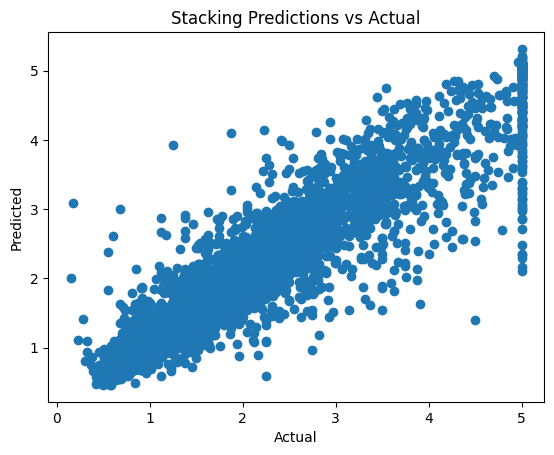

In [12]:
plt.scatter(y_test, final_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Stacking Predictions vs Actual")
plt.show()

## Error Distribution

Insight: Points closer to diagonal = better predictions.

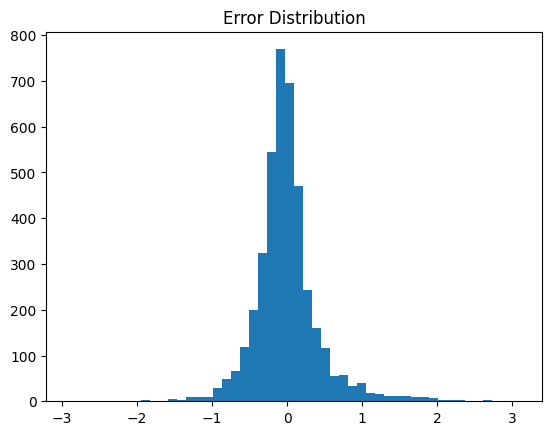

In [13]:
errors = y_test - final_preds

plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.show()

A centered and narrow distribution indicates lower prediction error and better model stability.

### Key Takeaways
- Stacking combines multiple models effectively
- OOF predictions prevent data leakage
- Model diversity improves performance
- Simple meta-models often work best